# GPU Accelerated Hyperbolic Tangent Polynomial Approximations

Here we develop GPU accelerated functions for computing polynomial approximations of the hyperbolic tangent.

The algorithms are implemented in numpy and cupy to compare performance.


In [1]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def polyval_gpu(p, e, x):
    """Evaluates a polynomial

    Params:
    p - The coefficients of the polynomial, cupy vector
    e - The the exponents of the polynomial, cupy vector
    x - The independent variable, cupy vector

    Returns:
    result -- The evaluated polynomial
    """

    result = cp.zeros(cp.shape(x))

    for coef, exp in zip(p, e):
        result = result + coef * x ** exp
    
    return result 


def polyval_cpu(p, e, x):
    """Evaluates a polynomial

    Params:
    p - The coefficients of the polynomial, cupy vector
    e - The the exponents of the polynomial, cupy vector
    x - The independent variable, cupy vector

    Returns:
    result -- The evaluated polynomial
    """

    result = np.zeros(np.shape(x))

    for coef, exp in zip(p, e):
        result = result + coef * x ** exp
    
    return result 


def factorial_gpu(n):
    """Computes a factorial on the GPU

    Vector n is supported but not matrix n.  This routine
    is most useful when the element-wise factorial of a set
    of similarly sized numbers needs to be computer.  This
    routine is not efficient when the variance in the size
    of the elements of n is large.
    
    Params:
    n -- number to compute the factorial for; can be a row vector
    
    Returns:
    result -- n!
    """
    n_max = cp.max(n)
    n_mat = cp.tile(n, (int(n_max), 1))
    subtractions = cp.arange(0, n_max, dtype=cp.int64)
    sub_mat = cp.tile(
        cp.transpose(subtractions.reshape(1, -1)),
        (1, cp.shape(n_mat)[1])
    )
    q = n_mat - sub_mat
    q[q <= 0] = 1
    result = cp.prod(q, axis=0)
    return result


def factorial_cpu(n):
    """Computes a factorial on the CPU

    Vector n is supported but not matrix n.  This routine
    is most useful when the element-wise factorial of a set
    of similarly sized numbers needs to be computer.  This
    routine is not efficient when the variance in the size
    of the elements of n is large.
    
    Params:
    n -- number to compute the factorial for; can be a row vector
    
    Returns:
    result -- n!
    """
    n_max = np.max(n)
    n_mat = np.tile(n, (int(n_max), 1))
    subtractions = np.arange(0, n_max, dtype=np.int64)
    sub_mat = np.tile(
        np.transpose(subtractions.reshape(1, -1)),
        (1, np.shape(n_mat)[1])
    )
    q = n_mat - sub_mat
    q[q <= 0] = 1
    result = np.prod(q, axis=0)
    return result


def compute_alpha_tanh_coefs_gpu(big_m, epsilon, dxi, v_max):
    """Computes alpha coefficients for a tanh nonlinearity using the GPU
    
    Params:
    big_m -- Number of terms in the expansion
    epsilon -- Small number for lower limit of integration
    dxi -- The step size for numerical integration
    v_max -- The maximum range of validity of the integral

    Returns:
    (alpha, exponents)
        alpha is a vector of alpha coefficients for a tanh nonlinearity
        exponents is a vector of the exponents belonging to each alpha
    """

    # Determine the upper bound of the integral
    q = 2*big_m + 3
    kappa_v = np.math.factorial(q) ** (1/q) / v_max

    # Get a vector of indicies
    m_indicies = cp.arange(1, big_m + 1, 1)
    k_indicies = cp.arange(1, 2*big_m + 1, 2)

    # Construct a matrix of variables of integration
    xi = cp.arange(epsilon, kappa_v, dxi, dtype=cp.float64)
    xi_mat = cp.tile(xi, (big_m, 1))

    # Construct a matrix of exponents
    exponents_mat_shape = (1, cp.shape(xi_mat)[1])
    exponents_mat = cp.tile(
        cp.transpose(k_indicies.reshape(1, -1)),
        exponents_mat_shape
    )

    # Construct a matrix of csch terms
    csch_term = cp.reciprocal(cp.sinh(cp.pi/2*xi))
    csch_mat = cp.tile(csch_term, (big_m, 1))

    # Construct a matrix of integrands
    integrand_mat = cp.multiply(cp.power(xi_mat, exponents_mat), csch_mat)

    # Construct a vector of integrals
    integrals = cp.sum(integrand_mat, axis=1)*dxi

    # Construct the coefficients from the indicies
    coefs = (-1) ** (m_indicies - 1) / factorial_gpu(k_indicies)

    alpha_coefs = cp.multiply(integrals, coefs)
    exponents = k_indicies

    return (alpha_coefs, exponents)
    
def compute_alpha_tanh_coefs_cpu(big_m, epsilon, dxi, v_max):
    """Computes alpha coefficients for a tanh nonlinearity using the GPU
    
    Params:
    big_m -- Number of terms in the expansion
    epsilon -- Small number for lower limit of integration
    dxi -- The step size for numerical integration
    v_max -- The maximum range of validity of the integral

    Returns:
    (alpha, exponents)
        alpha is a vector of alpha coefficients for a tanh nonlinearity
        exponents is a vector of the exponents belonging to each alpha
    """

    # Determine the upper bound of the integral
    q = 2*big_m + 3
    kappa_v = np.math.factorial(q) ** (1/q) / v_max

    # Get a vector of indicies
    m_indicies = np.arange(1, big_m + 1, 1)
    k_indicies = np.arange(1, 2*big_m + 1, 2)

    # Construct a matrix of variables of integration
    xi = np.arange(epsilon, kappa_v, dxi, dtype=np.float64)
    xi_mat = np.tile(xi, (big_m, 1))

    # Construct a matrix of exponents
    exponents_mat_shape = (1, np.shape(xi_mat)[1])
    exponents_mat = np.tile(
        np.transpose(k_indicies.reshape(1, -1)),
        exponents_mat_shape
    )

    # Construct a matrix of csch terms
    csch_term = np.reciprocal(np.sinh(np.pi/2*xi))
    csch_mat = np.tile(csch_term, (big_m, 1))

    # Construct a matrix of integrands
    integrand_mat = np.multiply(np.power(xi_mat, exponents_mat), csch_mat)

    # Construct a vector of integrals
    integrals = np.sum(integrand_mat, axis=1)*dxi

    # Construct the coefficients from the indicies
    coefs = (-1) ** (m_indicies - 1) / factorial_cpu(k_indicies)

    alpha_coefs = np.multiply(integrals, coefs)
    exponents = k_indicies

    return (alpha_coefs, exponents)


<StemContainer object of 3 artists>

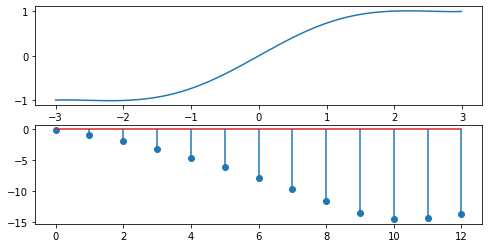

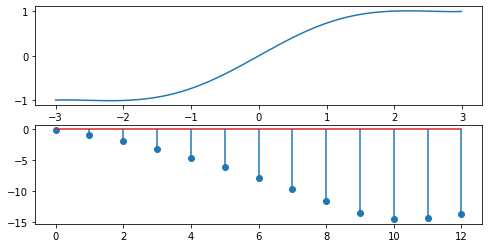

In [3]:
v_max = 6
alpha_coefs, exponents = compute_alpha_tanh_coefs_gpu(
    big_m=13, epsilon=1e-16, dxi=1e-4, v_max=v_max)

x = cp.arange(-3, 3, 0.01)
y = polyval_gpu(alpha_coefs, exponents, x)

fig, axs = plt.subplots(2, 1, figsize=(8,4))
axs[0].plot(x.get(), y.get())
axs[1].stem(np.log10(np.abs(alpha_coefs.get())))

alpha_coefs, exponents = compute_alpha_tanh_coefs_cpu(
    big_m=13, epsilon=1e-16, dxi=1e-4, v_max=v_max)

x = np.arange(-3, 3, 0.01)
y = polyval_cpu(alpha_coefs, exponents, x)

fig, axs = plt.subplots(2, 1, figsize=(8,4))
axs[0].plot(x, y)
axs[1].stem(np.log10(np.abs(alpha_coefs)))